<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-ZapataGonzalez/Evaluacion2/ZapataGonzalez/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np


from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
 # Configuración Estética Definitiva para Google Colab (Fuerza LaTeX real del sistema)
plt.rcParams.update({
    "text.usetex": True,                     # ¡ACTIVAMOS EL COMPILADOR REAL DE LATEX!
    "font.family": "serif",                  # Familia serif obligatoria
    "font.serif": ["Computer Modern Roman"], # Fuente académica por excelencia
    "text.latex.preamble": r"\usepackage[utf8]{inputenc} \usepackage[T1]{fontenc} \usepackage{amsmath}", # Soporte nativo para español
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Estética de guardado
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

print('Configuración de Fuentes Científicas con LaTeX Real OK')

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

In [59]:
!python generar_enunciado.py 3951
!python generar_datos.py 3951

Enunciado generado para cédula 3951: enunciado_3951.md
Los parámetros: K=25, iteraciones=3000, η=0.02, n=12/régimen, régimen foco=0, compresión 85%
Datos generados para cédula 3951: X=(36, 256), y=(36,), t=(256,)
Guardado en datos_3951.npz


In [39]:
!sudo apt-get install texlive-latex-recommended
!pip install pdflatex


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-latex-recommended is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 64 not upgraded.


In [40]:
!pip install --upgrade jax jaxlib

# Capa Fourier
El siguiente código contiene los resultados pedidos en la parte "capa fourier (15 pts)" de la rúbrica. (función de la capa de fourier, comparación con np.fft (evidencias matemáticas) y reporte de energía)

In [76]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import numpy as np
import matplotlib.pyplot as plt

# Configuración de parámetros establecidos por el enunciado
K = 25              # Número de frecuencias
hidden_dim = 2 * K  # 2K = 50 neuronas ocultas
n_features = 256    # Tamaño de la señal (t)
eta = 0.02          # Learning rate
iteraciones = 3000  # Número de iteraciones

# Carga de datos correspondientes a la cédula 3951
datos = np.load("datos_3951.npz")
X_train = jnp.array(datos['X'])
y_train = np.array(datos['y'])
t = jnp.array(datos['t'])

# 1. FUNCIÓN QUE CONSTRUYE LA CAPA FOURIER
def construir_capa_fourier(n_features=256, K=25):
    t_arr = jnp.linspace(0, 1, n_features, endpoint=False)
    W1_list = []
    for k in range(1, K + 1):
        W1_list.append(jnp.cos(2 * jnp.pi * k * t_arr) * jnp.sqrt(2.0 / n_features))
        W1_list.append(jnp.sin(2 * jnp.pi * k * t_arr) * jnp.sqrt(2.0 / n_features))
    return jnp.stack(W1_list, axis=0)

W1_fourier_init = construir_capa_fourier(n_features, K)

# ARQUITECTURA DE LA RED NEURONAL (Dos capas: W1 -> tanh -> W2)
def forward(params, x):
    phi = jnp.tanh(jnp.dot(params['W1'], x))
    x_hat = jnp.dot(params['W2'], phi)
    return x_hat

forward_batch = vmap(forward, in_axes=(None, 0))

@jit
def loss_fn(params, X):
    X_hat = forward_batch(params, X)
    return jnp.mean((X_hat - X) ** 2)

@jit
def update(params, X, lr):
    grads = grad(loss_fn)(params, X)
    updated_params = {
        'W1': params['W1'] - lr * grads['W1'],
        'W2': params['W2'] - lr * grads['W2']
    }
    return updated_params

#Reporte de datos
energia_media = float((X_train**2).mean())

print("CAPA FOURIER Y ENERGÍA")

print(f"Energía media del dataset ((X**2).mean()): {energia_media:.3f}\n")


# Poryeccion de W1
proyeccion = jnp.dot(W1_fourier_init, X_train[0])
mag_capa_k1 = jnp.sqrt(proyeccion[0]**2 + proyeccion[1]**2)

# FFT
fft_np = np.fft.rfft(X_train[0])
# Debemos multiplicar por el mismo factor de normalización que W1: sqrt(2/N)
factor_norm = np.sqrt(2.0 / n_features)
mag_fft_k1 = np.abs(fft_np[1]) * factor_norm

print("EVIDENCIA DE TRANSFORMADA DE FOURIER (k=1):")
print(f"Magnitud calculada por Capa W1:  {mag_capa_k1:.6f}")
print(f"Magnitud calculada por np.fft:   {mag_fft_k1:.6f}")
print(f"Diferencia absoluta:             {abs(mag_capa_k1 - mag_fft_k1):.2e}")


CAPA FOURIER Y ENERGÍA
Energía media del dataset ((X**2).mean()): 0.621

EVIDENCIA DE TRANSFORMADA DE FOURIER (k=1):
Magnitud calculada por Capa W1:  4.835033
Magnitud calculada por np.fft:   4.835033
Diferencia absoluta:             0.00e+00


# Entrenamiento, reconstrucción y comparación
El código a continuación contiene la red entrenada con las inicializaciones; Fourier y de manera aleatoria, el error reportado para cada caso y la medición de las iteraciones para bajar el error relativo.
Además genera las gráficas;
perdida L vs iteraciones para ambas iniciaciones superpuestas, el contraste del régimen especificacdo en las instruciones (μ=0.0) y para cada régimen la señal original y la reconstrucción.

Entrenando redes...

ENTREGABLE 3: MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)
-> Inicialización Aleatoria: No alcanzó el umbral en 3000 iteraciones (Mínimo alcanzado: 0.775)
-> Inicialización de Fourier: No alcanzó el umbral en 3000 iteraciones (Mínimo alcanzado: 0.819)



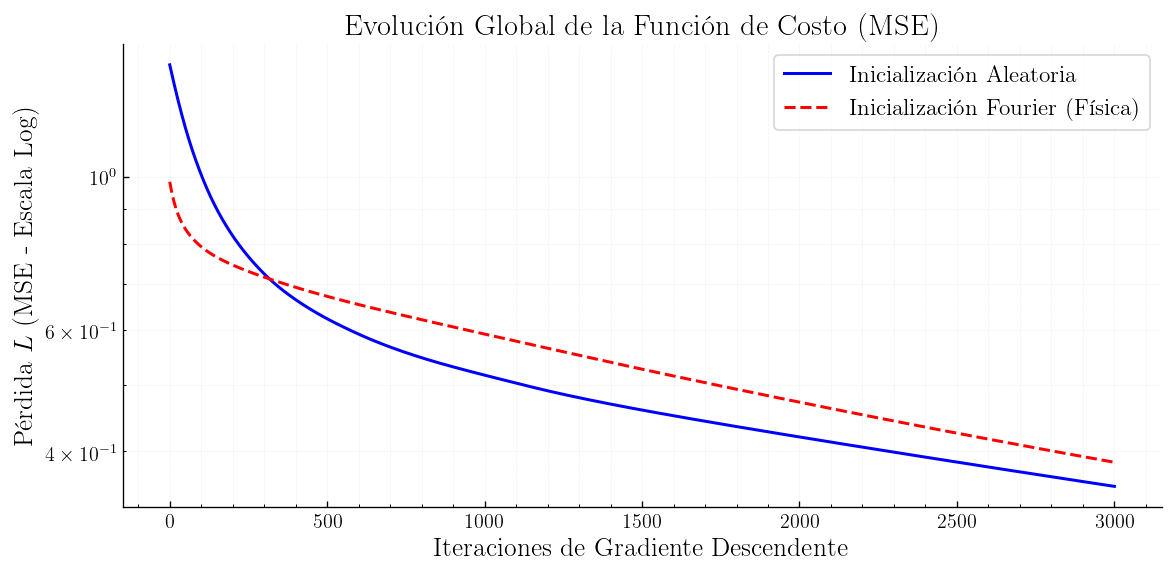

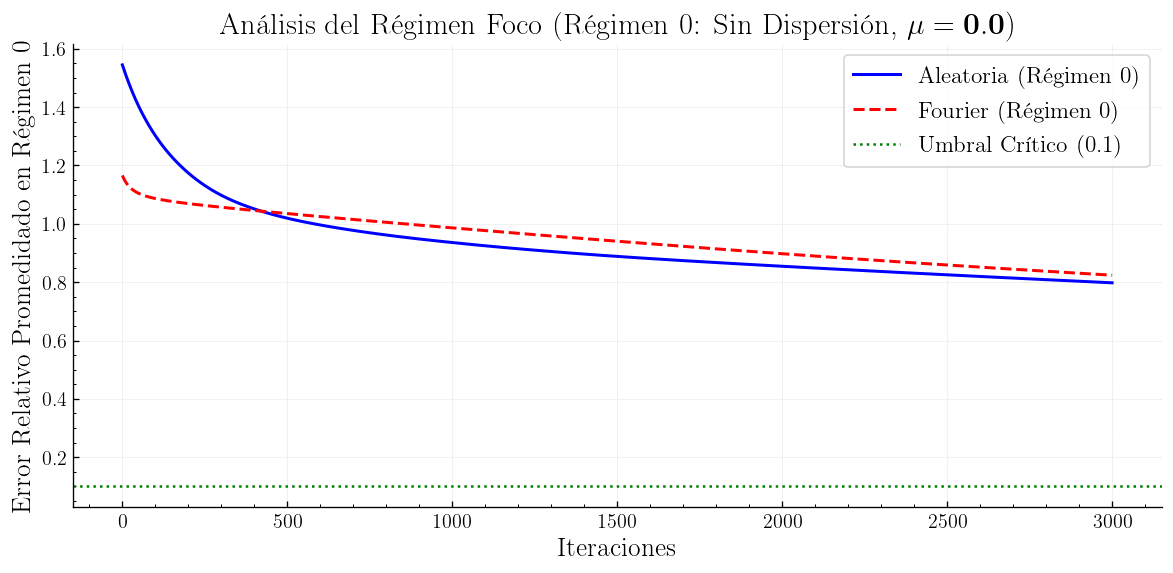

ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN
Régimen 0 (mu=0.0): Fourier Err = 0.9655 | Aleatorio Err = 0.8694
Régimen 1 (mu=5.0): Fourier Err = 0.7103 | Aleatorio Err = 0.7053
Régimen 2 (mu=15.0): Fourier Err = 0.9317 | Aleatorio Err = 0.8309




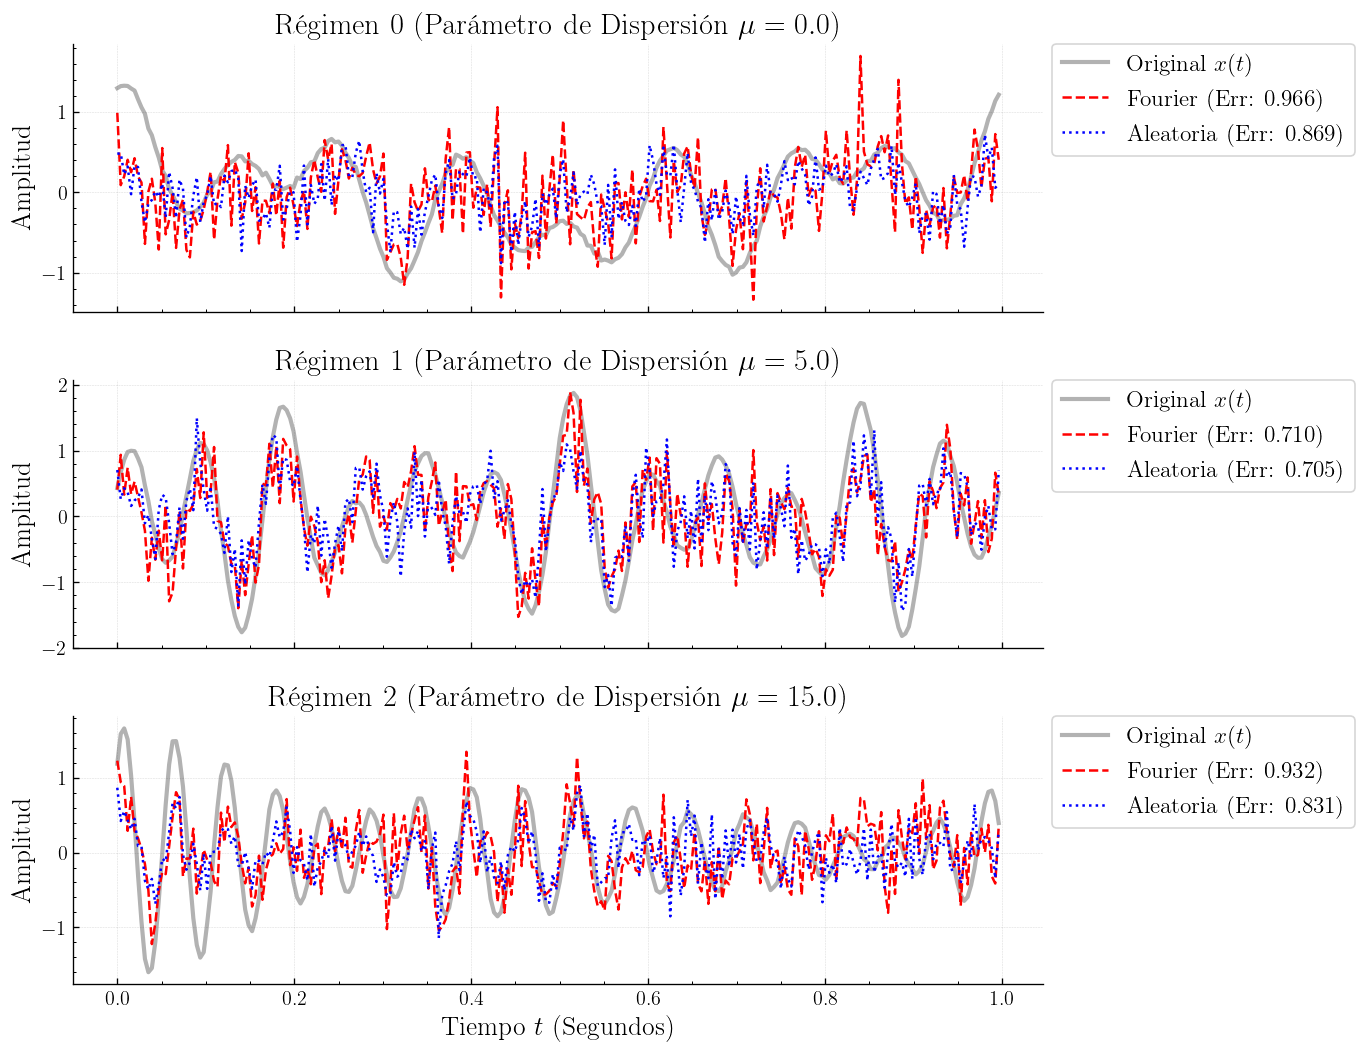

In [83]:
#Parte 1: iniciación y entrenamiento
# Semilla reproducible basada en tu ID
key = jax.random.PRNGKey(3951)
k1, k2 = jax.random.split(key)

params_rand = {
    'W1': jax.random.normal(k1, (hidden_dim, n_features)) * jnp.sqrt(2.0 / n_features),
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

params_four = {
    'W1': W1_fourier_init,
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

historial_loss_rand, historial_loss_four = [], []
historial_err_rand_global, historial_err_four_global = [], []
historial_err_rand_r0, historial_err_four_r0 = [], []

# Índice para Régimen 0 (Enfoque según instrucciones)
idx_regimen_foco = np.where(y_train == 0)[0]

p_rand = params_rand.copy()
p_four = params_four.copy()

print("Entrenando redes...")
for i in range(iteraciones + 1):
    p_rand = update(p_rand, X_train, eta)
    p_four = update(p_four, X_train, eta)

    loss_r = loss_fn(p_rand, X_train)
    loss_f = loss_fn(p_four, X_train)
    historial_loss_rand.append(loss_r)
    historial_loss_four.append(loss_f)

    x_hat_r_curr = np.array(forward_batch(p_rand, X_train))
    x_hat_f_curr = np.array(forward_batch(p_four, X_train))

    err_r_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_r_curr)
    err_f_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_f_curr)

    historial_err_rand_global.append(np.mean(err_r_individual))
    historial_err_four_global.append(np.mean(err_f_individual))

    historial_err_rand_r0.append(np.mean(err_r_individual[idx_regimen_foco]))
    historial_err_four_r0.append(np.mean(err_f_individual[idx_regimen_foco]))

# BÚSQUEDA DE UMBRAL
def buscar_iteracion_umbral(historial, umbral):
    for idx, val in enumerate(historial):
        if val < umbral: return f"{idx} iteraciones."
    return f"No alcanzó el umbral en 3000 iteraciones (Mínimo alcanzado: {min(historial):.3f})"

print("\n" + "="*60)
print("ENTREGABLE 3: MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)")
print(f"-> Inicialización Aleatoria: {buscar_iteracion_umbral(historial_err_rand_global, 0.1)}")
print(f"-> Inicialización de Fourier: {buscar_iteracion_umbral(historial_err_four_global, 0.1)}")
print("="*60 + "\n")

# VISUALIZACIÓN

# A. Pérdida Global
plt.figure(figsize=(10, 5))
plt.plot(historial_loss_rand, 'b-', label=r'$\text{Inicialización Aleatoria}$', linewidth=1.8)
plt.plot(historial_loss_four, 'r--', label=r'$\text{Inicialización Fourier (Física)}$', linewidth=1.8)
plt.yscale('log')
plt.xlabel(r'$\text{Iteraciones de Gradiente Descendente}$')
plt.ylabel(r'$\text{Pérdida } L \text{ (MSE - Escala Log)}$')
plt.title(r'$\mathbf{\text{Evolución Global de la Función de Costo (MSE)}}$')
plt.grid(True, which="both", ls=":")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# B. Régimen 0 (Enfoque de las instrucciones)
plt.figure(figsize=(10, 5))
plt.plot(historial_err_rand_r0, 'b-', label=r'$\text{Aleatoria (Régimen 0)}$', linewidth=1.8)
plt.plot(historial_err_four_r0, 'r--', label=r'$\text{Fourier (Régimen 0)}$', linewidth=1.8)
plt.axhline(y=0.1, color='g', linestyle=':', label=r'$\text{Umbral Crítico (0.1)}$')
plt.xlabel(r'$\text{Iteraciones}$')
plt.ylabel(r'$\text{Error Relativo Promedidado en Régimen 0}$')
plt.title(r'$\mathbf{\text{Análisis del Régimen Foco (Régimen 0: Sin Dispersión, } \mu=0.0)}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# C. Reconstrucciones finales para cada régimen
X_hat_final_rand = forward_batch(p_rand, X_train)
X_hat_final_four = forward_batch(p_four, X_train)
valores_mu = {0: "0.0", 1: "5.0", 2: "15.0"}

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

print("ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN")

for reg in [0, 1, 2]:
    idx = np.where(y_train == reg)[0][0]
    err_f = np.linalg.norm(X_hat_final_four[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])
    err_r = np.linalg.norm(X_hat_final_rand[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])

    print(f"Régimen {reg} (mu={valores_mu[reg]}): Fourier Err = {err_f:.4f} | Aleatorio Err = {err_r:.4f}")

    axs[reg].plot(t, X_train[idx], 'k-', label=r'$\text{Original } x(t)$', alpha=0.3, linewidth=2.5)
    axs[reg].plot(t, X_hat_final_four[idx], 'r--', label=r'$\text{Fourier (Err: ' + f'{err_f:.3f}' + ')}$')
    axs[reg].plot(t, X_hat_final_rand[idx], 'b:', label=r'$\text{Aleatoria (Err: ' + f'{err_r:.3f}' + ')}$')

    axs[reg].set_title(r'$\text{Régimen ' + str(reg) + r' (Parámetro de Dispersión } \mu = ' + valores_mu[reg] + r')$')
    axs[reg].set_ylabel(r'$\text{Amplitud}$')
    axs[reg].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.)
    axs[reg].grid(True)

axs[2].set_xlabel(r'$\text{Tiempo } t \text{ (Segundos)}$')
plt.tight_layout()
plt.subplots_adjust(right=0.80)
print("\n")
plt.show()